In [1]:
import openpyxl

def get_column_data_by_name(file_path, sheet_name, column_name):
    workbook = openpyxl.load_workbook(file_path)
    sheet = workbook[sheet_name]
    # 找到列名所在的列号
    column_index = None
    for cell in sheet[1]:
        if cell.value == column_name:
            column_index = cell.column
            break
    if column_index is None:
        raise ValueError(f"未找到列名: {column_name}")
    # 读取该列的数据
    column_data = []
    for row in sheet.iter_rows(min_row=2, min_col=column_index, max_col=column_index, values_only=True):
        column_data.append(row[0])
    return column_data

file_path = '/root/velon/control_info.xlsx'
sheet_name = 'Sheet1'

vel_ego = get_column_data_by_name(file_path, sheet_name, 'vel_ego')
vel_dob_prior_dist = get_column_data_by_name(file_path, sheet_name, 'vel_dob_prior_dist')
throttle_output = get_column_data_by_name(file_path, sheet_name, 'throttle_output')
brake_output = get_column_data_by_name(file_path, sheet_name, 'brake_output')

print(len(vel_ego))
print(len(vel_dob_prior_dist))
print(len(throttle_output))
print(len(brake_output))
print(type(vel_ego))

1493
1493
1493
1493
<class 'list'>


1493


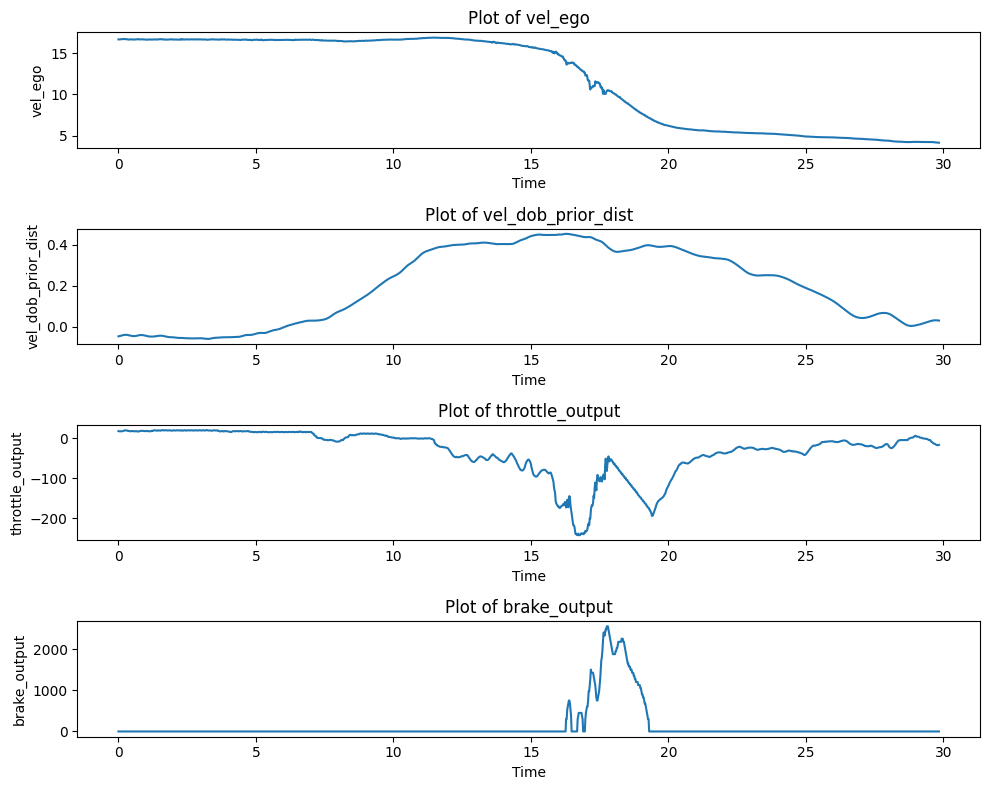

In [3]:
time = [i * 0.02 for i in range(1493)]
# 0.02是一个周期
print(len(time))
import matplotlib.pyplot as plt


# 创建一个图像
# plt.figure(figsize=(10, 6))

# # 绘制 y1, y2, y3, y4 的曲线
# plt.plot(time,vel_ego,label='vel_ego',color='black',linewidth=2)
# # plt.plot(time,vel_dob_prior_dist,label='vel_dob_prior_dist',color='red', linewidth=2)
# # plt.plot(time,throttle_output, label='throttle_output',color='blue', linewidth=2)
# # plt.plot(time,brake_output,label='brake_output',color='green', linewidth=2)

# # 设置标题和坐标轴标签
# plt.title('Plot',fontweight='bold',fontsize=20)
# plt.xlabel('Time',fontweight='bold',fontsize=20)
# plt.ylabel('Values',fontweight='bold',fontsize=20)

# # 调整刻度标签的字体大小
# plt.xticks(fontsize=12)
# plt.yticks(fontsize=12)

# # TODO：
# #add more config字体

# # 显示图例
# plt.legend()
# plt.savefig('plot.png', format='png')
# # 显示图像
# plt.show()

# 创建一个包含4个子图的画布
fig, axs = plt.subplots(4, 1, figsize=(10, 8))

# 绘制第一个图
axs[0].plot(time, vel_ego)
axs[0].set_title('Plot of vel_ego')
axs[0].set_xlabel('Time')
axs[0].set_ylabel('vel_ego')

# 绘制第二个图
axs[1].plot(time, vel_dob_prior_dist)
axs[1].set_title('Plot of vel_dob_prior_dist')
axs[1].set_xlabel('Time')
axs[1].set_ylabel('vel_dob_prior_dist')

# 绘制第三个图
axs[2].plot(time, throttle_output)
axs[2].set_title('Plot of throttle_output')
axs[2].set_xlabel('Time')
axs[2].set_ylabel('throttle_output')

# 绘制第四个图
axs[3].plot(time, brake_output)
axs[3].set_title('Plot of brake_output')
axs[3].set_xlabel('Time')
axs[3].set_ylabel('brake_output')

# 调整子图之间的间距
plt.tight_layout()

# 显示图像
plt.show()

In [4]:
import numpy as np

class ExtendedKalmanFilter:
    def __init__(self):
        self.F = None
        self.H = None
        self.Q = None
        self.R = None
        self.P = None
        self.x0 = None
        self.x = None
        self.u = None
        self.S = None
        self.K = None

    def init(self, F, H, Q, R, P, x0):
        self.F = F
        self.H = H
        self.Q = Q
        self.R = R
        self.P = P
        self.x0 = x0
        self.x = x0.copy()
        self.S = np.zeros((H.shape[0], H.shape[0]))
        self.K = np.zeros((F.shape[0], H.shape[0]))

    def WheelSpeedModel(self, x, u):
        a0, a1, a2, a3, a4 = 0.00090958, -0.000284835, -0.000054324, 0.93518205, -0.124167715
        return (a0 * u[0] + a1 * u[1] + a2 * x[0] * x[0] + a3 * u[2] + a4) * 0.02 + x[0]

    def GetJacobian(self, x):
        a2 = -0.000054324
        self.F[0, 0] = 2 * a2 * 0.02 * x[0] + 1

    def SetU(self, u):
        self.u = u

    def Update(self, z):
        self.x[0] = self.WheelSpeedModel(self.x, self.u)
        self.GetJacobian(self.x)
        P_prior = self.F @ self.P @ self.F.T + self.Q
        y_r = z - self.H @ self.x
        self.S = self.H @ P_prior @ self.H.T + self.R
        self.K = P_prior @ self.H.T @ np.linalg.inv(self.S)
        self.x += self.K @ y_r
        I = np.eye(self.F.shape[0])
        self.P = (I - self.K @ self.H) @ P_prior

    def GetState(self):
        return self.x
# 输入： vel_ego && x0_val
# 创建一个EKF实例
ego_speed_ekf = ExtendedKalmanFilter()
x0_val = vel_ego[0]

# 定义系统矩阵
F = np.array([[0]])  # 状态转移矩阵
H = np.array([[1.0]])  # 观测矩阵
Q = np.array([[0.8]])  # 过程噪声协方差矩阵
R = np.array([[1]])  # 观测噪声协方差矩阵
P = np.array([[1.0]])  # 估计误差协方差矩阵
x0 = np.array([x0_val])  # 初始状态

# 初始化EKF
ego_speed_ekf.init(F, H, Q, R, P, x0)

time = []
speed_ekf_filter = []

for i in range(len(vel_ego)):
    u = np.array([throttle_output[i], brake_output[i], vel_dob_prior_dist[i]])
    ego_speed_ekf.SetU(u)
    z_ego_ekf = np.array([vel_ego[i]])
    ego_speed_ekf.Update(z_ego_ekf)
    speed_ekf_filter.append(ego_speed_ekf.GetState().copy())
    time.append([0.02 * i])
# 重点关注对象
# speed_ekf_filter = [] #算法的输出

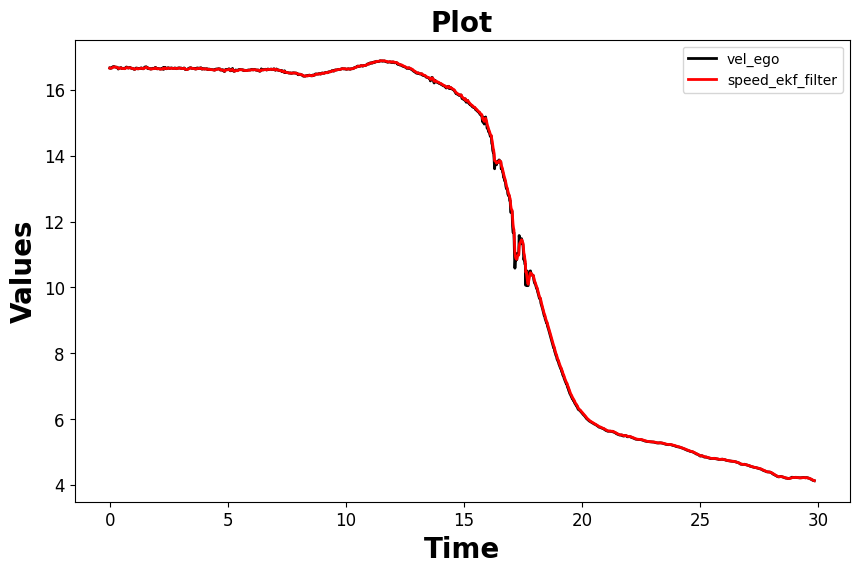

In [5]:
# 创建一个图像
plt.figure(figsize=(10, 6))

# 绘制 y1, y2, y3, y4 的曲线
plt.plot(time,vel_ego,label='vel_ego',color='black',linewidth=2)
plt.plot(time,speed_ekf_filter,label='speed_ekf_filter',color='red', linewidth=2)


# 设置标题和坐标轴标签
plt.title('Plot',fontweight='bold',fontsize=20)
plt.xlabel('Time',fontweight='bold',fontsize=20)
plt.ylabel('Values',fontweight='bold',fontsize=20)

# 调整刻度标签的字体大小
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.legend()

plt.show()

In [7]:
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display
from IPython.display import clear_output


# 创建一个输出区域
output = widgets.Output()

# 创建一个滑块
slider = widgets.IntSlider(min=1, max=10, step=1, value=5, description='滑块:')

# 定义一个回调函数
def update_plot(change):
    with output:
        clear_output(wait=True)  # 清除之前的输出
        plt.figure()
        x = np.linspace(0, 10, 100)
        y = np.sin(x * change['new'])
        plt.plot(x, y)
        plt.show()
        print(change['new'])

# 绑定滑块的变化事件到更新函数
slider.observe(update_plot, names='value')

# 显示滑块和输出区域
display(slider, output)

# 初始绘图
update_plot({'new': slider.value})



IntSlider(value=5, description='滑块:', max=10, min=1)

Output()